# 새로 나온 약은 얼마나 빨리 쓰이게 될까

## 궁금증

수업에서 배운 건 약이 어떻게 작동하는가였습니다.
그래서 처음엔 분자가 복잡할수록 시장에서 자리 잡기 어려울 거라 생각했습니다.

그런데 데이터를 열어보니 같은 표적을 노리는 항체 여섯 개가
환자 수에서 70배 차이가 났습니다. 기전도, 승인 시기도, 투여 방식도
사실상 같은데 말입니다.

**분자로는 설명이 안 되는 차이가 있었습니다.**

## 이 프로젝트가 도달한 곳

분자 특성이 아니라 **제형 선택과 진입 시점**이 확산을 갈랐습니다.
학부에서 배운 지식은 가설을 세우는 데 쓰였지만 답을 주지는 못했습니다.

기술 자체보다 **그 기술을 어떤 형태로 내놓고 언제 진입하느냐**가
시장 성과를 결정했다는 뜻입니다.

## 구성

| 부 | 내용 |
|---|---|
| 1부 | 신약 62개의 출시 후 채택 곡선 |
| 2부 | 치료제 50개의 하락 원인 분류 |
| 3부 | 같은 표적끼리 묶어 계열 내 비교 |
| 4부 | 규칙을 세우고 예측 검증 |
| 5부 | 확산 실패의 금액 환산 |

## 쓰는 통계

평균·중앙값 비교, 산점도, 선그래프.

## 가설

### 중심 질문: 무엇이 신약의 확산을 가르는가

**H1** 새로운 기전일수록 선례가 없어 초기 채택이 느리지만,
대체재가 없어 결국 시장을 가져간다.

**H2** 취급·투여가 복잡할수록 느리다.

H1은 약의 새로움을, H2는 쓰기 편한가를 봅니다.

### 미리 정하는 해석 기준

결과를 보고 해석을 끼워 맞추지 않기 위해 먼저 적어둡니다.

| 관측 | 결론 |
|---|---|
| 새로운 기전 약이 결국 높은 수준 도달 | H1 지지 |
| 새로움과 무관하게 편의성이 갈림 | H1 기각, H2 지지 |
| 둘 다 설명 못 함 | 제3의 요인 |

## 데이터

미국 Medicare Part B. 병원에서 투여하는 주사제가 대상이고,
연도별로 **약을 쓴 환자 수**가 공개됩니다. 2012–2024년.

금액이 아니라 환자 수라는 게 중요합니다. 금액은 약가가 바뀌면 흔들립니다.

data.cms.gov에서 받은 파일을 `data/`에 둡니다.
- Part B Spending by Drug (Historical Data zip)
- Manufacturer 파일 (제조사 정보)

승인 연도는 openFDA API로 조회합니다.
※ 재실행 시점에 따라 매칭 수가 달라질 수 있습니다. 본 결과는 2026-08-09 기준.

### 한계

- Medicare Advantage 가입자 제외 (전체의 35% 이상)
- 65세 이상 중심
- 병원 투여 주사제만

In [28]:
# ══════════════════════════════════════════════════════
#  셀 4  ·  환경 준비
# ══════════════════════════════════════════════════════

import sys, os, re, glob, zipfile, platform
import numpy as np
import pandas as pd
import requests, time
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

if platform.system() == "Windows":
    mpl.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    mpl.rc("font", family="AppleGothic")
mpl.rc("axes", unicode_minus=False)

PB_ZIP   = glob.glob("data/*Part B*Historical*.zip")[0]
MFR_FILE = glob.glob("data/*Manufacturer*.xlsx")[0]

print(f"python {sys.version.split()[0]} · pandas {pd.__version__}")
print("zip :", os.path.basename(PB_ZIP))
print("mfr :", os.path.basename(MFR_FILE))

python 3.12.10 · pandas 2.3.3
zip : Medicare Part B Spending by Drug- Excel Reports including Historical Data RY26_0.zip
mfr : Medicare-Part-B-Drug-Dashboard-Manufacturer-Drug_use - 260602.xlsx


In [29]:
# ══════════════════════════════════════════════════════
#  셀 5  ·  Part B 13년치 통합
#           연도별 Excel의 2단 헤더를 풀어 long format으로
# ══════════════════════════════════════════════════════

os.makedirs("work/pb", exist_ok=True)
with zipfile.ZipFile(PB_ZIP) as z:
    z.extractall("work/pb")
for f in glob.glob("work/pb/*.zip"):
    with zipfile.ZipFile(f) as z:
        z.extractall("work/pb/x")

METRICS = ["Total Spending", "Total Dosage Units",
           "Total Claims", "Total Beneficiaries"]


def parse_year_file(path):
    xl = pd.ExcelFile(path)
    sheet = [s for s in xl.sheet_names
             if "Spending" in s and "Utilization" in s][0]
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    # 주의: 파일 제목에도 "Calendar Years 2016-2020"이 있어
    #       정확히 'Calendar Year 20XX'인 칸만 찾아야 함
    hdr = None
    for i in range(12):
        if raw.iloc[i].astype(str).str.match(r"^Calendar Year\s*20\d\d\s*$").any():
            hdr = i
            break
    if hdr is None:
        return None

    yr_row = raw.iloc[hdr].ffill().astype(str)
    mt_row = raw.iloc[hdr + 1].astype(str)
    cols = []
    for y, m in zip(yr_row, mt_row):
        yy = re.search(r"(20\d\d)", str(y))
        cols.append(f"{m}__{yy.group(1)}" if (yy and str(m) != "nan") else str(m))

    d = raw.iloc[hdr + 2:].copy()
    d.columns = cols
    d = d.loc[:, ~pd.Index(cols).duplicated()]

    keep = ["Medicare Billing Code (HCPCS Code)", "Brand Name", "Generic Name"]
    recs = []
    for c in d.columns:
        if "__" not in str(c):
            continue
        met, yr = str(c).rsplit("__", 1)
        if met not in METRICS:
            continue
        t = d[keep].copy()
        t.columns = ["code", "brand", "generic"]
        t["year"], t["metric"] = int(yr), met
        t["value"] = pd.to_numeric(d[c], errors="coerce")
        recs.append(t)
    return pd.concat(recs, ignore_index=True) if recs else None


frames = [r for f in sorted(glob.glob("work/pb/x/*.xlsx"))
          if (r := parse_year_file(f)) is not None]

pb = (pd.concat(frames, ignore_index=True)
        .pivot_table(index=["code", "brand", "generic", "year"],
                     columns="metric", values="value", aggfunc="last")
        .reset_index())
pb["code"] = pb["code"].astype(str).str.strip()
pb = pb.sort_values("year").drop_duplicates(["code", "year"], keep="last")
pb["Total Beneficiaries"] = pd.to_numeric(pb["Total Beneficiaries"], errors="coerce")


def curve_of(code):
    return (pb[pb.code == code].sort_values("year")
              .set_index("year")["Total Beneficiaries"].dropna())


def spend_of(code):
    return (pb[pb.code == code].sort_values("year")
              .set_index("year")["Total Spending"].dropna())


print(f"{len(pb):,}행 · {pb.year.min()}–{pb.year.max()} · 약물 {pb.code.nunique()}개")

7,428행 · 2012–2024 · 약물 868개


# 1부. 표본 만들기

## 분석 대상 고르기

약이 868개 있지만 조건이 필요합니다.

- 2014~2019년 첫 등장 (출시 시점 파악)
- 2024년까지 관측
- 최고 환자 수 200명 이상

세 번째 기준은 10~1000명으로 여러 번 잘라본 결과입니다.
표본 수와 곡선 품질을 함께 보니 200명이 균형점이었습니다.

기준을 정할 때 신약만 남기는 게 핵심이었습니다.
청구코드가 새로 생겼을 뿐인 오래된 약이 섞이면
"출시 후 확산"이라는 개념 자체가 성립하지 않습니다.

In [30]:
# ══════════════════════════════════════════════════════
#  셀 7  ·  후보 추출 + FDA 승인연도 결합
# ══════════════════════════════════════════════════════

info = pb.groupby("code").agg(
    brand=("brand", "first"), generic=("generic", "first"),
    first_yr=("year", "min"), last_yr=("year", "max"),
    n_yr=("year", "size"), peak_benes=("Total Beneficiaries", "max"),
).reset_index()

cand = info[(info.first_yr.between(2014, 2019)) &
            (info.last_yr == 2024) &
            (info.n_yr >= 5) &
            (info.peak_benes >= 200)].copy()

# 중간에 빠진 연도 확인
cand["gaps"] = cand.code.map(
    lambda c: (lambda v: (v.index.max() - v.index.min() + 1) - len(v))(curve_of(c)))

print(f"후보 {len(cand)}개 · FDA 조회 시작\n")


def fda_year(brand):
    q = re.sub(r"\(.*?\)", "", str(brand)).replace("*", "").split(",")[0].strip()
    if len(q) < 3:
        return None
    try:
        r = requests.get("https://api.fda.gov/drug/drugsfda.json"
                         f'?search=openfda.brand_name:"{q}"&limit=5', timeout=15)
        if r.status_code != 200:
            return None
        dates = [int(s["submission_status_date"][:4])
                 for res in r.json().get("results", [])
                 for s in res.get("submissions", [])
                 if s.get("submission_type") == "ORIG" and s.get("submission_status_date")]
        return min(dates) if dates else None
    except Exception:
        return None


approvals = []
for b in cand.brand:
    approvals.append(fda_year(b))
    time.sleep(0.3)
cand["approval_yr"] = pd.array(approvals, dtype="Float64")

ok = cand.approval_yr.notna()
print(f"매칭 성공 {ok.sum()} / {len(cand)}")
print()
print("첫 등장 − 승인 연도 차이")
print((cand.loc[ok, "first_yr"] - cand.loc[ok, "approval_yr"])
      .astype(int).value_counts().sort_index().to_string())

후보 105개 · FDA 조회 시작

매칭 성공 88 / 105

첫 등장 − 승인 연도 차이
-3      1
 0      7
 1     25
 2     31
 3      3
 4      5
 5      2
 6      2
 8      1
 9      2
 10     1
 14     1
 18     1
 22     1
 23     1
 26     1
 30     1
 36     1
 40     1


In [31]:
# ══════════════════════════════════════════════════════
#  셀 8  ·  표본 확정
# ══════════════════════════════════════════════════════

T = cand[cand.approval_yr.notna()].copy()
T["approval_yr"] = T.approval_yr.astype(int)
T["lag"] = T.first_yr - T.approval_yr

sel = T[(T.lag.between(0, 3)) &
        (T.approval_yr.between(2012, 2018)) &
        (T.gaps == 0)].copy()

APPROVAL = dict(zip(sel.code, sel.approval_yr))   # 재현성용 고정

print(f"최종 표본 {len(sel)}개\n")
print("승인 연도별")
print(sel.approval_yr.value_counts().sort_index().to_string())

최종 표본 62개

승인 연도별
approval_yr
2012     4
2013     7
2014    11
2015     8
2016     6
2017    10
2018    16


### 데이터 처리에서 마주친 함정

**1. 첫 등장 연도 ≠ 출시 연도**
아세타졸아미드(1976년 승인)가 2014년 첫 등장으로 잡혔습니다.
청구코드 신설 때문입니다. FDA 승인 연도를 붙여 차이 0~3년만 남겼습니다.

**2. HCPCS 코드가 중간에 바뀜**
리툭시맙은 2019년 J9310 → J9312로 변경. 새 코드만 쓰면 이전이 사라집니다.

**3. 성분명 문자열로는 계열이 안 묶임**
Darzalex(Daratumumab)와 Darzalex Faspro(Daratumumab-Hyaluronidase-Fihj)가
별개로 잡혀 자기 잠식을 놓칠 뻔했습니다.
계열은 수작업 매핑으로 묶고, 자기 잠식과 경쟁 패배는 제조사로 구분했습니다.

**4. 지나친 문자열 정리는 다른 약을 합침**
프로드러그 접두사를 뗀다고 Ziv-Aflibercept를 aflibercept로 만들었더니
Zaltrap(대장암)과 Eylea(황반변성)가 한 계열이 됐습니다.

문자열 규칙만 믿으면 안 되고, 성분명을 눈으로 확인해야 했습니다.

In [32]:
# ══════════════════════════════════════════════════════
#  셀 10  ·  확산 지표 산출
# ══════════════════════════════════════════════════════

rows = []
for _, r in sel.iterrows():
    v = curve_of(r.code)
    s = pd.Series(v.values, index=v.index - r.approval_yr)
    s = s[s.index >= 0]
    if len(s) < 4:
        continue
    peak, last = s.max(), s.iloc[-1]
    rows.append({
        "code": r.code, "brand": r.brand, "generic": r.generic,
        "approval_yr": r.approval_yr,
        "정점": int(peak), "정점t": int(s.idxmax()), "최근": int(last),
        "하락률": round((last - peak) / peak * 100, 1),
        "성장중": bool(s.idxmax() == s.index.max()),
    })

D = pd.DataFrame(rows)

print(f"{len(D)}개\n")
print(f"아직 성장 중        : {D.성장중.sum()}개")
print(f"정점 후 10% 이상 하락 : {(D.하락률 <= -10).sum()}개")
print()
print("정점 도달 시점 (승인 후 몇 년)")
print(D.정점t.value_counts().sort_index().to_string())

62개

아직 성장 중        : 24개
정점 후 10% 이상 하락 : 31개

정점 도달 시점 (승인 후 몇 년)
정점t
2      8
3      4
4     10
5      5
6     15
7      4
8      4
9      4
10     4
11     4


## 전제가 깨졌습니다

62개 중 **31개가 정점을 찍고 10% 이상 내려왔습니다.** 정확히 절반입니다.
아직 성장 중인 건 24개(39%)뿐입니다.

저는 신약이 출시 후 성장해서 어느 수준에서 안정된다고 생각했습니다.
실제로는 봉우리 모양입니다.

정점 시점은 승인 후 2년부터 11년까지 넓게 퍼져 있고 6년이 가장 많습니다.

"얼마나 빨리 퍼지나"만이 아니라 **"얼마나 오래 버티나"**를 봐야 합니다.

# 2부. 왜 내려왔나

절반이 정점 후 하락했습니다. 원인이 하나가 아닐 것 같아
제품과 성분 전체를 함께 봅니다.

같은 하락이라도 회사가 스스로 옮긴 것인지 남에게 뺏긴 것인지는
전혀 다른 이야기입니다. 제조사 정보로 이 둘을 갈라봅니다.

In [33]:
# ══════════════════════════════════════════════════════
#  셀 13  ·  약물 유형 분류 + 하락 원인 판정
# ══════════════════════════════════════════════════════

mfr = pd.read_excel(MFR_FILE, sheet_name="Manufacturer Summary", header=2)
mfr.columns = ["code", "desc", "brand", "generic", "manufacturer"]
mfr = mfr[mfr.code.astype(str).str.match(r"^[A-Z0-9]{5}$")].copy()
mfr["code"] = mfr.code.astype(str).str.strip()
mfr_map = mfr.groupby("code")["manufacturer"].apply(
    lambda s: set(s.dropna().astype(str)))

BIOSIM_STEMS = ("infliximab|rituximab|bevacizumab|trastuzumab|filgrastim|"
                "epoetin|ranibizumab|adalimumab|etanercept|tocilizumab")


def classify(r):
    b, g = str(r.brand).lower(), str(r.generic).lower()
    # 예: "Epoetin Alfa-Epbx" → epoetin + " alfa" + -epbx
    if re.search(rf"({BIOSIM_STEMS})[a-z\s]*-[a-z]{{4}}\b", g):
        return "바이오시밀러"
    if "hyaluronidase" in g:
        return "제형변경"
    if "hyaluronate" in g:
        return "관절강주사"
    if "vaccine" in b or "vaccine" in g:
        return "백신"
    if any(x in g for x in ["gadoterate", "sulfur hexafluoride", "perflutren"]):
        return "조영제"
    if "immun glob" in g or "igg" in g:
        return "면역글로불린"
    return "치료제"


D["category"] = D.apply(classify, axis=1)
D.loc[D.brand.astype(str).str.contains("Kadcyla|Enhertu", na=False),
      "category"] = "치료제"          # ADC는 시밀러가 아니라 신약
targets = D[D.category == "치료제"].copy()

print("약물 유형 분포")
print("─" * 50)
print(D.category.value_counts().to_string())
print()


def family_of(g):
    s = str(g).lower().replace("*", "")
    s = re.sub(r"\(.*?\)", "", s)
    s = re.split(r"[/+]", s)[0]
    s = re.sub(r"-hyaluronidase.*$", "", s)
    s = re.sub(r"-[a-z]{4}\b", "", s)
    return re.sub(r"^fos-?", "", s).strip()      # ziv/ado/fam은 다른 약이라 유지


pb["family"] = pb.generic.map(family_of)

MANUAL_FAMILY = {
    "J9145": "daratumumab", "J9144": "daratumumab",
    "J8655": "netupitant",  "J1454": "netupitant",
}
pb["family"] = [MANUAL_FAMILY.get(c, f) for c, f in zip(pb.code, pb.family)]

rows = []
for _, r in targets.iterrows():
    fam  = MANUAL_FAMILY.get(r.code, family_of(r.generic))
    solo = curve_of(r.code)
    famc = (pb[pb.family == fam].groupby("year")["Total Beneficiaries"]
              .sum().reindex(solo.index).dropna())
    if len(famc) == 0 or famc.max() == 0:
        continue

    sd = (solo.iloc[-1] - solo.max()) / solo.max() * 100
    fd = (famc.iloc[-1] - famc.max()) / famc.max() * 100

    me   = mfr_map.get(r.code, set())
    sibs = pb.loc[(pb.family == fam) & (pb.code != r.code), "code"].unique()
    same = [c for c in sibs if me & mfr_map.get(c, set())]

    kind = ("유지·성장" if sd > -20 else
            ("자기잠식" if same else "경쟁패배") if fd > -10 else
            "계열쇠퇴" if fd < sd - 5 else "시장이탈")

    rows.append({"brand": r.brand, "family": fam,
                 "제품하락": round(sd, 1), "성분하락": round(fd, 1),
                 "동일사형제": len(same), "유형": kind})

G = pd.DataFrame(rows)

print("═" * 70)
print(f"치료제 {len(targets)}개\n")
print(G.유형.value_counts().to_string())
print()
print("하락 사례")
print("─" * 70)
print(G[G.유형 != "유지·성장"].sort_values("제품하락").to_string(index=False))

약물 유형 분포
──────────────────────────────────────────────────
category
치료제       50
바이오시밀러     9
조영제        2
제형변경       1

══════════════════════════════════════════════════════════════════════
치료제 50개

유형
유지·성장    31
시장이탈     16
자기잠식      2
경쟁패배      1

하락 사례
──────────────────────────────────────────────────────────────────────
                 brand                         family  제품하락  성분하락  동일사형제   유형
               Zaltrap                ziv-aflibercept -97.6 -97.6      0 시장이탈
               Akynzeo                     netupitant -97.4   0.0      1 자기잠식
              Orbactiv        oritavancin diphosphate -83.9 -28.7      1 시장이탈
              Darzalex                    daratumumab -82.4   0.0      1 자기잠식
Testosterone Enanthate         testosterone enanthate -81.2 -81.2      0 시장이탈
              Onpattro patisiran sodium,lipid complex -75.1 -75.1      0 시장이탈
                Sustol                    granisetron -74.8 -74.8      0 시장이탈
               Bendeka               bendamus

## 하락 원인이 세 가지로 나뉩니다

치료제 50개 중 31개는 유지·성장했고, 19개가 하락했습니다.
하락한 19개를 나눠보면 이렇습니다.

| 유형 | 제품 | 성분 | 개수 | 사례 |
|---|---|---|---|---|
| 자기 잠식 | ↓ | → | 2 | Darzalex → Faspro, Akynzeo |
| 경쟁 패배 | ↓ | → | 1 | Iluvien → Yutiq (다른 회사) |
| 시장 이탈 | ↓ | ↓ | 16 | Zaltrap, Sustol, Onpattro |

Darzalex는 IV가 -82% 하락했지만 SC 버전이 시장을 가져가
**성분 전체로는 성장**했습니다. 실패가 아니라 성공입니다.
제조사 정보 없이는 대실패로 잘못 셀 뻔했습니다.

### 이 분류의 한계

시장이탈 16개 중 Kadcyla, Perjeta, Bavencio, Tecentriq은
**같은 성분 경쟁이 아니라 같은 표적 경쟁에서 밀린 것**입니다.
성분 단위로는 못 잡습니다. 3부에서 표적 단위로 다시 봅니다.

### Onpattro가 인상적입니다

siRNA를 임상에 처음 성공시킨 약인데 정점 338명, 지금 84명입니다.
기술적으로는 획기적인데 시장은 미미했습니다.
**"새로움"과 "채택"이 무관할 수 있다는 반례**입니다.

# 3부. 같은 표적끼리 비교하기

성분 단위로는 표적 경쟁을 못 잡습니다.
Kadcyla가 Enhertu에 밀린 건 성분이 달라 안 보입니다.

같은 표적을 노리는 약을 손으로 묶으면 조건이 통제됩니다.
표적도 기전도 승인 시기도 비슷한데 결과만 다른 상황이 만들어집니다.
**남는 차이가 곧 답입니다.**

In [34]:
# ══════════════════════════════════════════════════════
#  셀 16  ·  경쟁 계열 매핑
# ══════════════════════════════════════════════════════

COMPETITIVE_CLASS = {
    "PD-1/PD-L1": {"J9271": "Keytruda", "J9299": "Opdivo", "J9022": "Tecentriq",
                   "J9173": "Imfinzi", "J9023": "Bavencio", "J9119": "Libtayo",
                   "J9298": "Opdualag"},
    "IL-5 (천식)": {"J2182": "Nucala", "J0517": "Fasenra", "J2786": "Cinqair"},
    "지속형 항생제": {"J0875": "Dalvance", "J2407": "Orbactiv",
                 "J2406": "Kimyrsa", "J0121": "Nuzyra"},
    "HER2": {"J9355": "Herceptin", "J9354": "Kadcyla", "J9306": "Perjeta",
             "J9316": "Phesgo", "J9358": "Enhertu"},
    "CD20": {"J9310": "Rituxan(구)", "J9312": "Rituxan",
             "J9301": "Gazyva", "J2350": "Ocrevus"},
    "타크로리무스 서방형": {"J7508": "Astagraf XL", "J7503": "Envarsus XR"},
    "안구 삽입 스테로이드": {"J7313": "Iluvien", "J7314": "Yutiq", "J7311": "Retisert"},
    "벤다무스틴": {"J9034": "Bendeka", "J9036": "Belrapzo", "J9033": "Treanda"},
}
code2class = {c: k for k, d in COMPETITIVE_CLASS.items() for c in d}
targets["class"] = targets.code.map(code2class).fillna("단독")

print(targets["class"].value_counts().to_string())
print()
missing = [c for d in COMPETITIVE_CLASS.values()
           for c in d if c not in set(pb.code)]
print(f"데이터에 없는 코드: {missing if missing else '없음'}")

class
단독             28
PD-1/PD-L1      6
지속형 항생제         3
IL-5 (천식)       3
CD20            2
안구 삽입 스테로이드     2
타크로리무스 서방형      2
벤다무스틴           2
HER2            2

데이터에 없는 코드: 없음


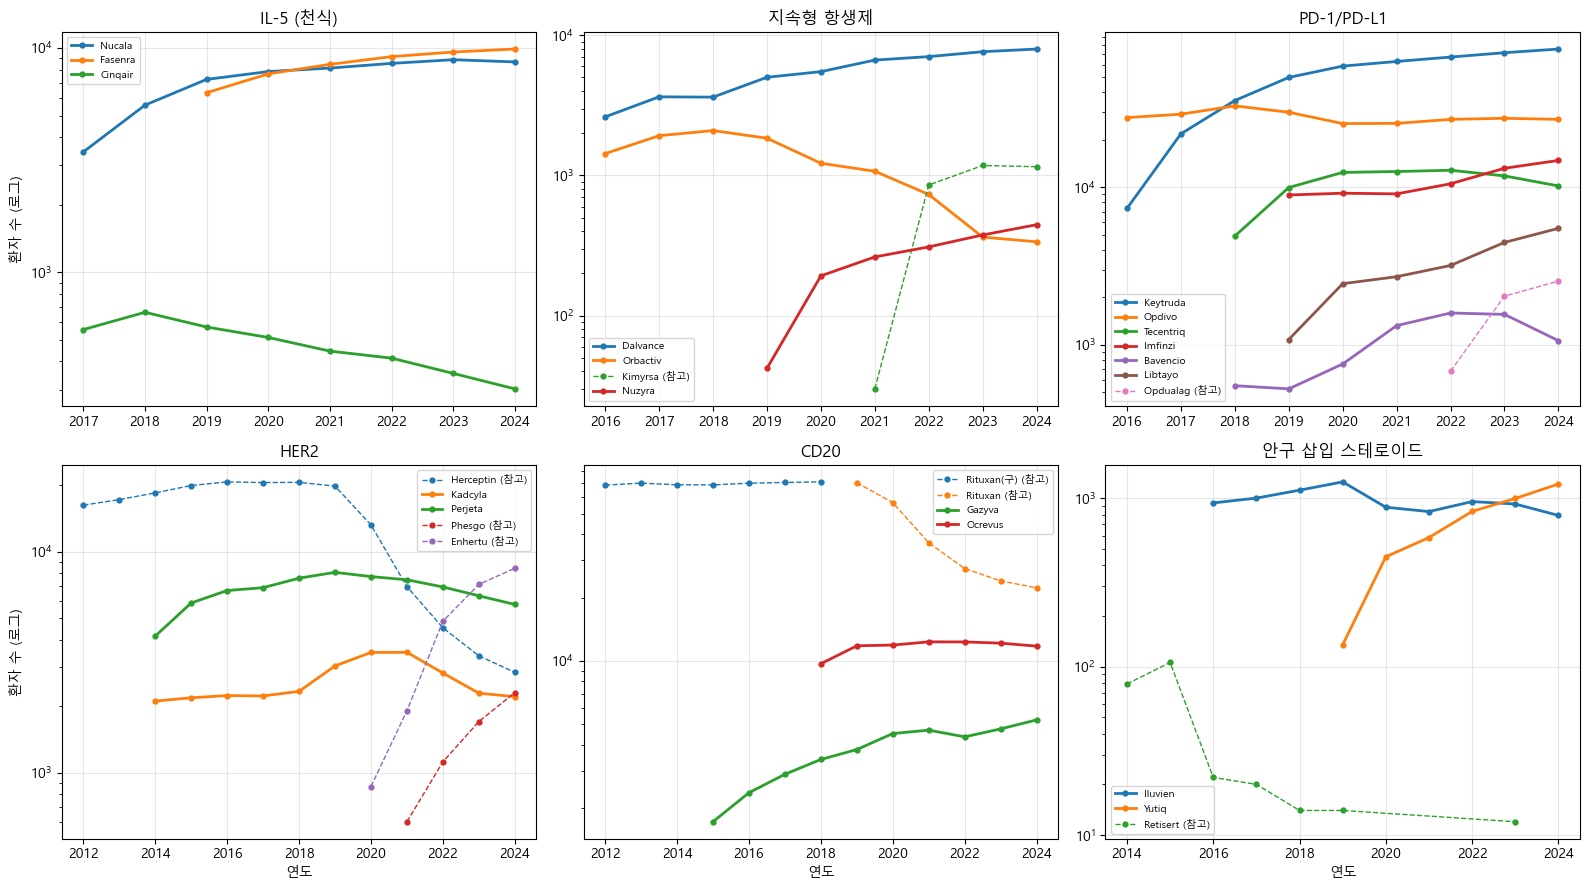

In [35]:
# ══════════════════════════════════════════════════════
#  셀 17  ·  계열별 곡선 (표본 밖 참고 약물 포함)
# ══════════════════════════════════════════════════════

SHOW = ["IL-5 (천식)", "지속형 항생제", "PD-1/PD-L1",
        "HER2", "CD20", "안구 삽입 스테로이드"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, cls in zip(axes.flat, SHOW):
    for code, name in COMPETITIVE_CLASS[cls].items():
        v = curve_of(code)
        if len(v) == 0:
            continue
        inside = code in set(targets.code)
        ax.plot(v.index, v.values, marker="o", ms=3.5,
                lw=2.0 if inside else 1.0, ls="-" if inside else "--",
                label=name + ("" if inside else " (참고)"))
    ax.set_title(cls)
    ax.set_yscale("log")
    ax.grid(alpha=.3)
    ax.legend(fontsize=7.5)

for ax in axes[1]:
    ax.set_xlabel("연도")
for ax in axes[:, 0]:
    ax.set_ylabel("환자 수 (로그)")
plt.tight_layout()
plt.show()

## 그림에서 읽은 것

**IL-5** — Nucala·Fasenra는 나란히 오르고 Cinqair만 내려옵니다.
셋 다 IL-5 관련 항체인데 Cinqair만 정맥주사입니다.

**지속형 항생제** — Kimyrsa가 2021년 진입해 Orbactiv를 넘어섰습니다.
둘은 **같은 성분인데 투여 시간만 3시간에서 1시간으로 줄인 것**입니다.

**PD-1/PD-L1** — 여섯 약이 전부 정맥주사인데 Keytruda 75,361명,
Bavencio 1,062명으로 70배 차이입니다. Opdivo는 2016년 Keytruda의 4배였다가
2017년 역전당했습니다. **투여 방식으로는 설명이 안 됩니다.**

**HER2** — Herceptin이 후속 세대에 밀리고, Kadcyla는 Enhertu 진입과 함께
꺾이고, Perjeta는 같은 회사 Phesgo로 옮겨갔습니다.

In [36]:
# ══════════════════════════════════════════════════════
#  셀 19  ·  투여 편의성 코딩
#           출처: 각 제품 FDA 허가사항
#                 Dosage and Administration 항목
# ══════════════════════════════════════════════════════

ADMIN = {
    "J2182": ("Nucala",   "SC",  "고정", 5),
    "J0517": ("Fasenra",  "SC",  "고정", 5),
    "J2786": ("Cinqair",  "IV",  "체중", 30),
    "J0875": ("Dalvance", "IV",  "고정", 30),
    "J2407": ("Orbactiv", "IV",  "고정", 180),
    "J2406": ("Kimyrsa",  "IV",  "고정", 60),
    "J0121": ("Nuzyra",   "IV",  "고정", 30),
    "J9271": ("Keytruda", "IV",  "고정", 30),
    "J9299": ("Opdivo",   "IV",  "고정", 30),
    "J9022": ("Tecentriq","IV",  "고정", 60),
    "J9023": ("Bavencio", "IV",  "고정", 60),
    "J9173": ("Imfinzi",  "IV",  "고정", 60),
    "J9119": ("Libtayo",  "IV",  "고정", 30),
    "J9306": ("Perjeta",  "IV",  "고정", 60),
    "J9354": ("Kadcyla",  "IV",  "체중", 90),
    "J9301": ("Gazyva",   "IV",  "고정", 240),
    "J2350": ("Ocrevus",  "IV",  "고정", 210),
    "J7313": ("Iluvien",  "이식", "고정", 5),
    "J7314": ("Yutiq",    "이식", "고정", 5),
    "J7508": ("Astagraf", "경구", "체중", 5),
    "J7503": ("Envarsus", "경구", "체중", 5),
    "J9034": ("Bendeka",  "IV",  "체중", 10),
    "J9036": ("Belrapzo", "IV",  "체중", 10),
}

P = pd.DataFrame(
    [{"code": c, "brand": b, "경로": r, "용량": d, "시간": t,
      "class": code2class.get(c, "단독")}
     for c, (b, r, d, t) in ADMIN.items()])

for i, r in P.iterrows():
    v = curve_of(r.code)
    P.loc[i, "정점"] = v.max()
    P.loc[i, "최근"] = v.iloc[-1]
    P.loc[i, "하락률"] = round((v.iloc[-1] - v.max()) / v.max() * 100, 1)

P[["정점", "최근"]] = P[["정점", "최근"]].astype(int)
P["상대시간"] = (P.시간 / P.groupby("class").시간.transform("min")).round(2)
P["승인"] = P.code.map(APPROVAL)

print(f"코딩 {len(P)}개")
print(P.sort_values(["class", "시간"]).to_string(index=False))

코딩 23개
 code     brand 경로 용량  시간       class    정점    최근   하락률  상대시간     승인
J2350   Ocrevus IV 고정 210        CD20 12327 11764  -4.6  1.00 2017.0
J9301    Gazyva IV 고정 240        CD20  5252  5252   0.0  1.14 2013.0
J9306   Perjeta IV 고정  60        HER2  8055  5766 -28.4  1.00 2012.0
J9354   Kadcyla IV 체중  90        HER2  3501  2206 -37.0  1.50 2013.0
J2182    Nucala SC 고정   5   IL-5 (천식)  8872  8671  -2.3  1.00 2015.0
J0517   Fasenra SC 고정   5   IL-5 (천식)  9899  9899   0.0  1.00 2017.0
J2786   Cinqair IV 체중  30   IL-5 (천식)   663   302 -54.4  6.00 2016.0
J9271  Keytruda IV 고정  30  PD-1/PD-L1 75361 75361   0.0  1.00 2014.0
J9299    Opdivo IV 고정  30  PD-1/PD-L1 32846 26951 -17.9  1.00 2014.0
J9119   Libtayo IV 고정  30  PD-1/PD-L1  5482  5482   0.0  1.00 2018.0
J9022 Tecentriq IV 고정  60  PD-1/PD-L1 12812 10191 -20.5  2.00 2016.0
J9023  Bavencio IV 고정  60  PD-1/PD-L1  1591  1062 -33.2  2.00 2017.0
J9173   Imfinzi IV 고정  60  PD-1/PD-L1 14791 14791   0.0  2.00 2017.0
J9034   Bendeka IV 체중  10  

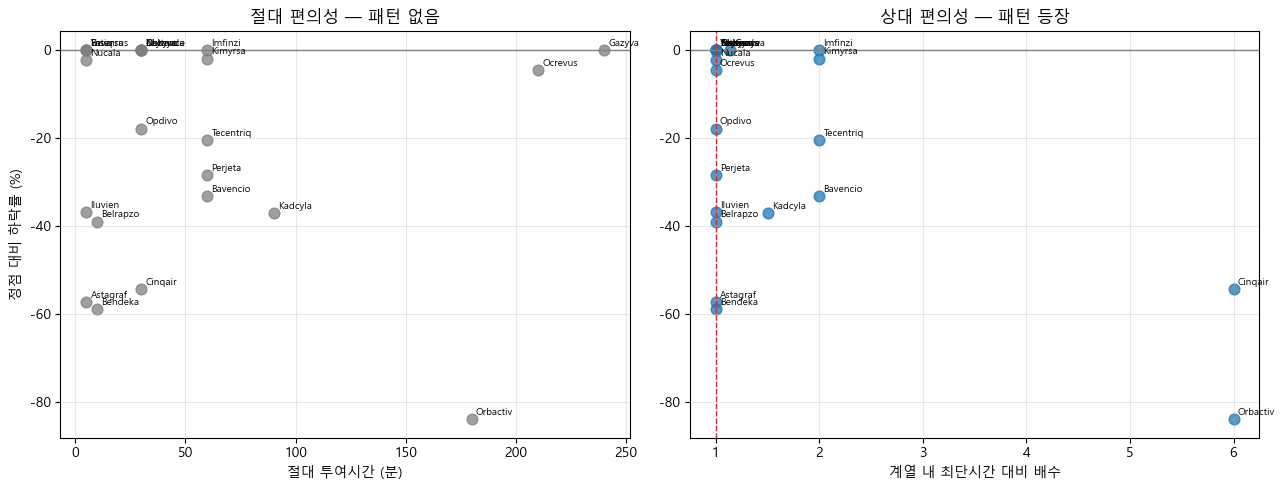

               n  평균하락  중앙하락
구간                          
1.0배 (계열 최선)  15 -16.3  -2.3
1.0~1.6배       2 -18.5 -18.5
1.6~2.5배       4 -13.9 -11.2
2.5배 이상        2 -69.2 -69.2


In [37]:
# ══════════════════════════════════════════════════════
#  셀 20  ·  절대 vs 상대 편의성
# ══════════════════════════════════════════════════════

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(P.시간, P.하락률, s=60, alpha=.75, c="tab:gray")
ax[1].scatter(P.상대시간, P.하락률, s=60, alpha=.75, c="tab:blue")

for a, x in zip(ax, ["시간", "상대시간"]):
    for _, r in P.iterrows():
        a.annotate(r.brand, (r[x], r.하락률), fontsize=7,
                   xytext=(3, 3), textcoords="offset points")
    a.axhline(0, c="gray", lw=1)
    a.grid(alpha=.3)

ax[0].set(xlabel="절대 투여시간 (분)", ylabel="정점 대비 하락률 (%)",
          title="절대 편의성 — 패턴 없음")
ax[1].axvline(1, c="tab:red", ls="--", lw=1)
ax[1].set(xlabel="계열 내 최단시간 대비 배수",
          title="상대 편의성 — 패턴 등장")

plt.tight_layout()
plt.show()

# 구간별 요약
P["구간"] = pd.cut(P.상대시간, [0.9, 1.01, 1.6, 2.5, 100],
                 labels=["1.0배 (계열 최선)", "1.0~1.6배", "1.6~2.5배", "2.5배 이상"])
print(P.groupby("구간", observed=True)
       .agg(n=("brand", "size"), 평균하락=("하락률", "mean"),
            중앙하락=("하락률", "median")).round(1).to_string())

## 발견 1 — 편의성은 상대적이다

절대 투여시간과 성과에는 상관이 없습니다.

    Gazyva   240분    0.0%   ← 가장 오래 걸리는데 멀쩡
    Bendeka   10분  -58.8%   ← 가장 짧은데 무너짐

**계열 내 상대값으로 바꾸니 패턴이 나옵니다.**

    1.0배 (계열 최선)  n=15  중앙 -2.3   평균 -16.3
    1.0~1.6배         n=2   중앙 -18.5
    1.6~2.5배         n=4   중앙 -11.2
    2.5배 이상         n=2   중앙 -69.2

Gazyva가 4시간인데 멀쩡한 이유는 **더 편한 대안이 없기 때문**입니다.
Cinqair가 30분인데 무너진 이유는 **5분 피하주사 대안이 있기 때문**입니다.

**"얼마나 불편한가"가 아니라 "대안보다 불편한가"입니다.**

절대 기준으로 제형을 평가하면 안 되고,
그 시점에 시장에 무엇이 있는지를 함께 봐야 한다는 뜻입니다.

### 다만 1.0배 그룹에도 무너진 약이 있습니다

중앙값은 -2.3인데 평균은 -16.3입니다.

    Bendeka   1.0배  -58.8%
    Astagraf  1.0배  -57.2%
    Iluvien   1.0배  -36.8%

편의성이 계열 내 최선인데 무너졌습니다. 다음 절에서 확인하겠습니다.

In [38]:
# ══════════════════════════════════════════════════════
#  셀 22  ·  발견 2 — 후발 우위
# ══════════════════════════════════════════════════════

PAIRS = [
    ("J7313", "J7314", "안구 삽입 스테로이드"),
    ("J7508", "J7503", "타크로리무스 서방형"),
    ("J2407", "J2406", "지속형 항생제 (같은 성분)"),
    ("J9354", "J9358", "HER2 ADC"),
    ("J9306", "J9316", "HER2 (같은 회사)"),
]

names = {c: n for d in COMPETITIVE_CLASS.values() for c, n in d.items()}

rows = []
for e, l, cls in PAIRS:
    ev, lv = curve_of(e), curve_of(l)
    if len(ev) == 0 or len(lv) == 0:
        continue
    rows.append({
        "계열": cls,
        "선발": names.get(e, e),
        "선발_승인": APPROVAL.get(e, "-"),
        "선발_하락": round((ev.iloc[-1] - ev.max()) / ev.max() * 100, 1),
        "후발": names.get(l, l),
        "후발_첫등장": int(lv.index.min()),
        "후발_최근": int(lv.iloc[-1]),
    })

print("선발 vs 후발")
print("─" * 80)
print(pd.DataFrame(rows).to_string(index=False))
print()
print("※ 후발은 표본 밖 약물이 많아 승인 연도 대신 데이터 첫 등장 연도를 씀")

선발 vs 후발
────────────────────────────────────────────────────────────────────────────────
             계열          선발  선발_승인  선발_하락          후발  후발_첫등장  후발_최근
    안구 삽입 스테로이드     Iluvien   2014  -36.8       Yutiq    2019   1218
     타크로리무스 서방형 Astagraf XL   2013  -57.2 Envarsus XR    2016  15740
지속형 항생제 (같은 성분)    Orbactiv   2014  -83.9     Kimyrsa    2021   1154
       HER2 ADC     Kadcyla   2013  -37.0     Enhertu    2020   8410
   HER2 (같은 회사)     Perjeta   2012  -28.4      Phesgo    2021   2301

※ 후발은 표본 밖 약물이 많아 승인 연도 대신 데이터 첫 등장 연도를 씀


## 발견 2 — 편의성이 비슷하면 후발이 이긴다

편의성이 계열 내 최선인데도 무너진 약들의 공통점은 **먼저 나왔다는 것**입니다.

    Iluvien (2014) -36.8%  →  Yutiq     성장
    Astagraf(2013) -57.2%  →  Envarsus  성장
    Orbactiv(2014) -83.9%  →  Kimyrsa   유지
    Kadcyla (2013) -37.0%  →  Enhertu   성장
    Perjeta (2012) -28.4%  →  Phesgo    성장

**H1과 반대 방향입니다.** H1은 "first-in-class가 자리를 잡으면 시장을
가져간다"였는데, 계열 내에서 먼저 나온 약이 반복적으로 밀립니다.

다만 first-in-class 여부를 따로 코딩하지 않았으므로
**직접 검증이 아니라 간접 확인**입니다.

Orbactiv → Kimyrsa는 같은 성분인데 투여 시간만 줄인 후발이
원조를 밀어낸 사례입니다.

### 진입 순서가 불리하게 작용합니다

다섯 사례 모두 선발이 밀렸고, 후발은 대체로 **같은 표적에 더 편한 제형**을
들고 왔습니다. 선발이 시장을 열어놓으면 후발이 그 위에서 개선판을 냅니다.

먼저 진입하는 것이 반드시 유리하지 않다는 뜻입니다.

# 4부. 규칙으로 예측해보기

여기까지는 이미 결과가 나온 약을 설명한 것입니다.
**설명과 예측은 다릅니다.** 사후에 이유를 붙이는 건 쉽고,
아직 모르는 대상에 적용해서 맞는지 보는 건 어렵습니다.

- **학습** 2012~2015년 승인 약 — 규칙을 세움
- **검증** 2016~2018년 승인 약 — 적용해 맞는지 확인

Kimyrsa 1개는 표본 선정 기준(승인 2012~2018, 첫 등장 차이 3년 이내)에
들지 않아 승인 연도가 없습니다. 학습·검증 양쪽에서 제외됩니다.

규칙은 발견 1에서 나온 것을 씁니다.

> 계열 내 최단 투여시간 대비 2.5배를 넘으면 크게 무너진다

In [39]:
# ══════════════════════════════════════════════════════
#  셀 25  ·  예측 검증
# ══════════════════════════════════════════════════════

train = P[P.승인.between(2012, 2015)].copy()
test  = P[P.승인.between(2016, 2018)].copy()

print(f"학습 {len(train)}개 · 검증 {len(test)}개 · "
      f"승인연도 없음 {P.승인.isna().sum()}개\n")

print("학습 구간: 임계값별 구분력")
print("─" * 62)
for th in [1.5, 2.0, 2.5, 3.0, 4.0]:
    hi, lo = train[train.상대시간 > th].하락률, train[train.상대시간 <= th].하락률
    if len(hi) == 0 or len(lo) == 0:
        print(f"  {th}배  한쪽이 비어 판정 불가")
        continue
    print(f"  {th}배  초과 {len(hi)}개 {hi.mean():6.1f}%  |  "
          f"이하 {len(lo)}개 {lo.mean():6.1f}%")

THRESHOLD, DECLINE = 2.5, -30
print(f"\n규칙: 상대시간 > {THRESHOLD}배 → 하락률 {DECLINE}% 이하 예측\n")

for df, name in [(train, "학습"), (test, "검증")]:
    df["예측"] = df.상대시간 > THRESHOLD
    df["실제"] = df.하락률 <= DECLINE
    fp = ((df.예측) & (~df.실제)).sum()
    fn = ((~df.예측) & (df.실제)).sum()
    print(f"■ {name} n={len(df)}  정확도 {(df.예측 == df.실제).mean():.0%}")
    print(f"    하락 예측했는데 안 무너짐 {fp}개 · 유지 예측했는데 무너짐 {fn}개")

print()
print("검증 구간 개별 결과")
print("─" * 72)
print(test.sort_values("상대시간")[
    ["brand", "class", "승인", "상대시간", "하락률", "예측", "실제"]
].assign(적중=lambda d: d.예측 == d.실제).to_string(index=False))

학습 12개 · 검증 10개 · 승인연도 없음 1개

학습 구간: 임계값별 구분력
──────────────────────────────────────────────────────────────
  1.5배  초과 1개  -83.9%  |  이하 11개  -21.7%
  2.0배  초과 1개  -83.9%  |  이하 11개  -21.7%
  2.5배  초과 1개  -83.9%  |  이하 11개  -21.7%
  3.0배  초과 1개  -83.9%  |  이하 11개  -21.7%
  4.0배  초과 1개  -83.9%  |  이하 11개  -21.7%

규칙: 상대시간 > 2.5배 → 하락률 -30% 이하 예측

■ 학습 n=12  정확도 67%
    하락 예측했는데 안 무너짐 0개 · 유지 예측했는데 무너짐 4개
■ 검증 n=10  정확도 80%
    하락 예측했는데 안 무너짐 0개 · 유지 예측했는데 무너짐 2개

검증 구간 개별 결과
────────────────────────────────────────────────────────────────────────
    brand       class     승인  상대시간   하락률    예측    실제    적중
  Fasenra   IL-5 (천식) 2017.0   1.0   0.0 False False  True
   Nuzyra     지속형 항생제 2018.0   1.0   0.0 False False  True
  Libtayo  PD-1/PD-L1 2018.0   1.0   0.0 False False  True
  Ocrevus        CD20 2017.0   1.0  -4.6 False False  True
 Belrapzo       벤다무스틴 2018.0   1.0 -39.0 False  True False
    Yutiq 안구 삽입 스테로이드 2018.0   1.0   0.0 False False  True
  Imfinzi  PD-1/PD-L1 2017.0   2.0

## 발견 3 — 편의성은 충분조건이지 필요조건이 아니다

    학습 12개  정확도 67%
    검증 10개  정확도 80%

정확도보다 **오류의 방향**이 정보입니다.

    하락 예측했는데 안 무너짐 : 0개
    유지 예측했는데 무너짐    : 학습 4개, 검증 2개

**한쪽으로만 틀립니다.** 편의성이 나쁘면 반드시 무너지지만,
편의성이 좋아도 무너지는 약이 있습니다.

### 놓친 약들

**학습 구간 4개** — Bendeka, Astagraf, Iluvien, Kadcyla
전부 상대시간 1.0~1.5배인데 무너졌습니다.
Astagraf·Iluvien은 후발에 밀렸고(발견 2), Bendeka는 계열 축소,
Kadcyla는 Enhertu에 밀린 경우입니다.

**검증 구간 2개**

- **Belrapzo(-39.0%)** — 벤다무스틴 계열 전체가 축소 중.
  개별 제품 문제가 아니라 치료 패러다임이 바뀐 경우
- **Bavencio(-33.2%)** — PD-1/PD-L1 안에서 Keytruda에 밀림.
  발견 2로 설명되는 쪽

**놓친 6개가 전부 발견 2(후발 우위) 또는 계열 축소로 설명됩니다.**
편의성 규칙만으로는 부족하고 **계열의 성장 여부와 계열 내 경쟁 순위**를
함께 봐야 합니다.

### 임계값에 대한 솔직한 기록

학습 구간에서 1.5~4.0배를 시험했는데 **결과가 전부 같았습니다.**
2.5배를 넘는 약이 Orbactiv 하나뿐이었기 때문입니다.

따라서 2.5배는 데이터가 골라준 값이 아니라 사실상 임의로 정한 값입니다.

# 5부. 얼마나 큰 문제인가

지금까지는 환자 수로 봤습니다. 금액으로 보면 순위가 달라지는지 확인합니다.

In [40]:
# ══════════════════════════════════════════════════════
#  셀 28  ·  확산 실패의 금액 환산
# ══════════════════════════════════════════════════════

rows = []
for _, r in P[P.하락률 <= -20].iterrows():
    sp = spend_of(r.code)
    if len(sp) == 0:
        continue
    rows.append({
        "brand": r.brand, "class": r["class"], "상대시간": r.상대시간,
        "환자_하락률": r.하락률,
        "정점지출_백만$": round(sp.max() / 1e6, 1),
        "최근지출_백만$": round(sp.iloc[-1] / 1e6, 1),
        "감소액_백만$": round((sp.max() - sp.iloc[-1]) / 1e6, 1),
        "정점연도": int(sp.idxmax()),
    })

E = pd.DataFrame(rows).sort_values("감소액_백만$", ascending=False)

print("정점 대비 20% 이상 하락한 약의 지출 변화")
print("─" * 88)
print(E.to_string(index=False))
print()
print(f"합계 감소액 : {E['감소액_백만$'].sum():,.0f} 백만 달러")
print()

# 편의성 문제 vs 경쟁 문제로 나눠 비교
편의성 = E[E.상대시간 > 2.5]["감소액_백만$"].sum()
경쟁   = E[E.상대시간 <= 2.5]["감소액_백만$"].sum()
print(f"상대시간 2.5배 초과 (편의성 문제) : {편의성:6.1f} 백만$")
print(f"상대시간 2.5배 이하 (경쟁 문제)   : {경쟁:6.1f} 백만$")
print()
print("※ Medicare Part B 65세 이상 FFS 가입자 기준. 전체 시장은 훨씬 큽니다.")

정점 대비 20% 이상 하락한 약의 지출 변화
────────────────────────────────────────────────────────────────────────────────────────
    brand       class  상대시간  환자_하락률  정점지출_백만$  최근지출_백만$  감소액_백만$  정점연도
  Bendeka       벤다무스틴   1.0   -58.8     233.2      56.2    176.9  2018
Tecentriq  PD-1/PD-L1   2.0   -20.5     777.8     677.7    100.1  2022
  Kadcyla        HER2   1.5   -37.0     182.5     142.2     40.3  2021
 Bavencio  PD-1/PD-L1   2.0   -33.2     123.4      97.9     25.5  2023
  Perjeta        HER2   1.0   -28.4     317.3     297.1     20.2  2022
 Belrapzo       벤다무스틴   1.0   -39.0      15.6       4.6     11.0  2022
 Orbactiv     지속형 항생제   6.0   -83.9       7.9       2.0      5.9  2018
  Iluvien 안구 삽입 스테로이드   1.0   -36.8      13.9       8.9      5.1  2019
  Cinqair   IL-5 (천식)   6.0   -54.4      13.1       8.6      4.5  2018
 Astagraf  타크로리무스 서방형   1.0   -57.2       6.8       2.6      4.2  2018

합계 감소액 : 394 백만 달러

상대시간 2.5배 초과 (편의성 문제) :   10.4 백만$
상대시간 2.5배 이하 (경쟁 문제)   :  383.3 백만$

※ Medicare 

## 발견 4 — 금액으로 보면 순위가 뒤집힌다

정점 대비 20% 이상 하락한 10개 약의 Medicare 지출 감소분은
**394 백만 달러**입니다.

    Bendeka     176.9  백만$   벤다무스틴 계열 축소
    Tecentriq   100.1          Keytruda에 밀림
    Kadcyla      40.3          Enhertu에 밀림
    Bavencio     25.5          Keytruda에 밀림
    Perjeta      20.2          Phesgo로 자기 잠식

그런데 원인별로 나누면 이렇습니다.

    편의성 문제 (2.5배 초과)  Orbactiv, Cinqair    10.4 백만$
    경쟁 문제  (2.5배 이하)  나머지 8개          383.3 백만$

**편의성은 예측하기 쉽지만 규모가 작고, 경쟁은 예측하기 어렵지만 규모가 큽니다.**

관리하기 쉬운 문제와 중요한 문제가 다르다는 뜻입니다.

이건 회사가 잃은 매출이 아니라 시장에서 사라진 규모입니다.
Medicare Part B 65세 이상 FFS 가입자에 한정되므로 실제 시장은 훨씬 큽니다.

# 결론

## 발견 네 가지

**1. 편의성은 상대적이다**
절대 투여시간은 무관합니다. 계열 내 최선 대비 얼마나 불편한가가 결정합니다.
Gazyva는 4시간인데 멀쩡하고 Cinqair는 30분인데 무너졌습니다.

**2. 편의성이 비슷하면 후발이 이긴다**
Iluvien→Yutiq, Astagraf→Envarsus, Orbactiv→Kimyrsa, Kadcyla→Enhertu.
계열 내에서 먼저 나온 약이 반복적으로 밀렸습니다. H1과 반대 방향입니다.

**3. 편의성은 충분조건이지 필요조건이 아니다**
검증 정확도 80%인데 오류가 한 방향으로만 났습니다.
편의성이 나쁘면 반드시 무너지지만, 좋아도 무너집니다.
놓친 6개는 전부 발견 2 또는 계열 축소로 설명됩니다.

**4. 금액으로 보면 순위가 뒤집힌다**
편의성 문제는 10.4 백만 달러, 경쟁 문제는 383.3 백만 달러.
예측하기 쉬운 문제와 중요한 문제가 다릅니다.

## 이 결과가 말하는 것

### 기술이 같아도 결과가 갈립니다

PD-1/PD-L1 계열 여섯 약은 조건이 거의 같습니다.
같은 표적, 비슷한 승인 시기, 30~60분 정맥주사.
그런데 2024년 환자 수는 Keytruda 75,361명, Bavencio 1,062명입니다.

기전이 같으니 "약이 더 좋아서"로는 설명할 수 없습니다.
**차이를 만든 건 분자 바깥에 있었습니다.**

### 무엇이 갈랐나

**제형** — IL-5 계열 셋 중 Cinqair만 무너졌습니다.
나머지 둘은 5분 피하주사, Cinqair는 30분 정맥주사입니다.

**진입 시점** — 다섯 사례 모두 먼저 나온 쪽이 졌습니다.
Orbactiv와 Kimyrsa는 성분이 같은데 투여 시간만 3시간에서 1시간으로
줄인 후발이 시장을 가져갔습니다.

### 관리하기 쉬운 것과 큰 것이 다릅니다

    제형 문제   예측 가능(정확도 80%)  ·   10.4 백만$
    경쟁 문제   예측 변수 못 찾음      ·  383.3 백만$

제형은 개발 단계에서 미리 판단할 수 있지만 규모가 작습니다.
경쟁 열위는 37배 큰 문제인데 사전에 알 방법을 찾지 못했습니다.

### 결론

임상 성공은 출발선이지 결승선이 아닙니다.
같은 기전으로 허가를 받아도 **어떤 형태로 내놓고 언제 진입하느냐**에 따라
시장 결과가 수십 배 갈립니다.

## 가설이 이렇게 옮겨갔습니다

    새로울수록 느리다 (H1)
        ↓
    편의성이 결정한다 (H2)
        ↓
    편의성은 충분조건일 뿐, 규모는 경쟁이 만든다 (최종)

## 한계

- Medicare Advantage 제외 (전체의 35% 이상), 65세 이상 중심
- 병원 투여 주사제만. 먹는 약과 자가주사는 없음
- 치료제 50개 중 경쟁 계열 22개만 심층 분석.
  학습 12개 · 검증 10개로 정확도 수치는 참고용
- **임계값 2.5배는 데이터가 고른 값이 아닙니다.** 학습 구간에서
  1.5~4.0배를 시험했으나 초과군이 항상 1개뿐이라 구분되지 않았습니다
- 투여 편의성은 각 제품 FDA 허가사항의 Dosage and Administration
  항목을 보고 손으로 코딩했습니다

## 못 한 것

- **H1(새로움 가설)을 직접 검증하지 못했습니다.** FDA의 first-in-class
  지정 정보를 붙이지 않아 간접 확인에 그쳤습니다.
- **경쟁 열위를 예측하는 규칙**을 만들지 못했습니다. 금액으로는 이쪽이
  훨씬 큰 문제인데, 사전에 관측 가능한 변수를 찾지 못했습니다.
- **PD-1/PD-L1에서 70배 격차가 난 이유**를 설명하지 못했습니다.
  적응증 확대 범위가 원인일 가능성이 크지만 확인하지 못했습니다.
- 지출 감소액은 계산했지만 **제형 개발 투자 대비 수익**으로 연결하지
  못했습니다. 개발비 정보가 필요합니다.